In [193]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib import ticker

# **1. Data collection / loading**


In [194]:
def load_excel_file(sheet_name):
    LOCAL_EXCEL_FILE_PATH = "../data/raw/covid_19_dataset.xlsx"
    REMOTE_EXCEL_FILE_PATH = "https://raw.githubusercontent.com/chetanchandel31/da-covid19/main/data/raw/covid_19_dataset.xlsx"
    try:
        return pd.read_excel(LOCAL_EXCEL_FILE_PATH, sheet_name=sheet_name)
    except FileNotFoundError:
        return pd.read_excel(REMOTE_EXCEL_FILE_PATH, sheet_name=sheet_name, engine="openpyxl")
    except Exception as e:
        print("unexpected error while loading data", e)
        raise


df_deaths = load_excel_file("covid_19_deaths_v1")
df_confirmed = load_excel_file("covid_19_confirmed_v1")
df_recovered = load_excel_file("covid_19_recovered_v1")

# **2. Data inspection / exploration**


In [195]:
for name, df in [("Deaths", df_deaths), ("Confirmed", df_confirmed), ("Recovered", df_recovered)]:
    display(Markdown(f"### {name}:"))
    display(Markdown(f"**Shape:** {df.shape}"))

    # ~494 columns, too much noise in output
    # print("Columns:", end=" ")
    # print(*df.columns, sep=", ")

    non_date_cols = ["Province/State", "Country/Region", "Lat", "Long"]
    date_cols = [c for c in df.columns if c not in non_date_cols]
    display(Markdown(f"**Non date columns**: {len(non_date_cols)} ({', '.join(non_date_cols)})"))
    display(
        Markdown(f"**Date columns:** {len(date_cols)} (from {date_cols[0]} to {date_cols[-1]})")
    )
    display(Markdown(f"*Subset of date column headers*: {date_cols[0:15]}"))

    df_dtypes = df.dtypes
    display(Markdown("**Column wise data types**:"))
    display(df_dtypes)

    date_col_dtypes = set()
    for idx, val in df_dtypes.items():
        if idx not in non_date_cols:
            date_col_dtypes.add(val)

    display(Markdown(f"**Unique data types for date-columns' values:** {list(date_col_dtypes)}"))
    display(
        Markdown(
            f"**Highest date:** {max(pd.to_datetime(date_cols, errors='coerce', format='mixed', dayfirst=False))}"
        )
    )

    display(
        Markdown(
            f"**Null values in column headers**(includes potential null dates): {df.columns.isna().sum()}"
        )
    )
    display(Markdown(f"**Null values across entire dataset**: {df.isna().sum().sum()}"))
    print()
    display(Markdown("---"))

### Deaths:

**Shape:** (276, 498)

**Non date columns**: 4 (Province/State, Country/Region, Lat, Long)

**Date columns:** 494 (from 1/22/20 to 5/29/21)

*Subset of date column headers*: ['1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20', '1/28/20', '1/29/20', '1/30/20', '1/31/20', datetime.datetime(2020, 1, 2, 0, 0), datetime.datetime(2020, 2, 2, 0, 0), datetime.datetime(2020, 3, 2, 0, 0), datetime.datetime(2020, 4, 2, 0, 0), datetime.datetime(2020, 5, 2, 0, 0)]

...

**Unique data types for date-columns' values:** [dtype('float64'), dtype('int64')]

**Highest date:** 2021-12-05 00:00:00

**Null values in column headers**(includes potential null dates): 0

**Null values across entire dataset**: 194

---

#### **Structure of raw dataset**

- **Shape of data:** Each sheet has 498 columns, suggesting cases recorded over same dates in each sheet. However, the sheet with recovered cases has fewer rows(261) than the other 2 sheets(containing 276 rows each), suggesting recovered cases recorded over comparatively fewer locations.

- **Datatypes of non-date column values:** Location related columns(`Province/State`, `Country/Region`) are correctly typed as `str` and the coordinates(`Lat` and `Long` columns) are `float64`.

- **Datatypes under date-column values:** Values present in date-columns under "confirmed cases" are correctly typed as `int64` confirming zero `NaN` values there. In the other 2 sheets, individual date-columns are typed as either `int64` or `float64`, some columns are one, some are the other, indicating `NaN`s are present in at least some of those columns (`NaN` forces a column to upcast to `float64`), since "number of cases" generally can't be a decimal number.

- **Discrepancy in column header datatype:**
  - Date _column headers_, however, are inconsistently typed - a mix of `str` (e.g. `'1/22/20'`) and `datetime.datetime` objects (e.g. `datetime(2020, 1, 2)`), likely due to inconsistent cell formatting in the original Excel file.
  - As a result, in "subset of date column headers", after dates from January, we see dates like `['2020-01-02 00:00:00', '2020-02-02 00:00:00', '2020-03-02 00:00:00', '2020-04-02 00:00:00']` which reads as `2 Jan 2020, 2 Feb 2020, 2 March 2020...` instead of `1 Feb 2020, 2 Feb 2020, 3 Feb 2020...` as the automatic conversion is swapping month and date because of inconsistent date string format.

    Another observation is `2021-12-05 00:00:00`(5 Dec 2021) being read as the `highest date` while from our raw inspection of columns, the dates seem to be chronologically ordered, in case this assumption holds, the last date among column headers, which should also be the `highest date` is `5/29/21`(29 May 2021).

  - This will need to be normalized to a single consistent type before melting
    to long format for time-series analysis.

- **Null values:**
  - **Column headers:** The column headers contain 0 null values which is important to know because it tells us we don't have to worry about imputing missing values before normalizing dates(as those are a subset of column headers in this dataset).
  - **Dataset:** Although, the entire dataset itself does contain 195 null values in "deaths" dataset and 194 null values in "confirmed" and "recovered" each, which will have to be dealt with moving forward.


# **3. Data cleaning**


### **3.1 Normalize inconsistent dates**


In [196]:
# re-run this cell using "run-all", never in isolation because then it'll read the reassigned `df` and before-after comparison will be meaningless
def convert_date_string(date_string):
    date_string = str(date_string)
    if date_string[-3] == "/":
        return date_string

    date_part = date_string.split(" ")[0]
    year_part, month_part, day_part = date_part.split("-")

    # swap month and day
    month_part, day_part = day_part, month_part

    # strip 0s and trim year
    if month_part[0] == "0":
        month_part = month_part[-1]
    if day_part[0] == "0":
        day_part = day_part[-1]
    year_part = year_part[2:]

    return f"{month_part}/{day_part}/{year_part}"


for name, df in [("Deaths", df_deaths), ("Confirmed", df_confirmed), ("Recovered", df_recovered)]:
    display(Markdown(f"### {name}:"))

    display(Markdown("#### **Before conversion:**"))

    non_date_cols = ["Province/State", "Country/Region", "Lat", "Long"]
    date_cols = [c for c in df.columns if c not in non_date_cols]

    display(Markdown(f"**Subset of date column headers**: {df.columns.to_list()[0:20]}"))
    max_date = max(pd.to_datetime(date_cols, format="mixed", dayfirst=False))
    last_date = pd.to_datetime(df.columns[-1])
    display(
        Markdown(
            f"**Max date:** {max_date}, **Last date:** {last_date}, **Max date = Last date:** {max_date == last_date}"
        )
    )

    display(Markdown("#### **After conversion:**"))

    df.columns = pd.concat(
        [
            pd.Series(non_date_cols),
            pd.to_datetime(pd.Series(date_cols).apply(convert_date_string), format="mixed"),
        ]
    )

    updated_date_cols = [c for c in df.columns if c not in non_date_cols]
    display(Markdown(f"**Subset of date column headers**: {df.columns.to_list()[0:20]}"))
    max_date = max(updated_date_cols)
    last_date = df.columns[-1]
    display(
        Markdown(
            f"**Max date:** {max_date}, **Last date:** {last_date}, **Max date = Last date:** {max_date == last_date}"
        )
    )
    display(Markdown("---"))

### Deaths:

#### **Before conversion:**

**Subset of date column headers**: ['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20', '1/28/20', '1/29/20', '1/30/20', '1/31/20', datetime.datetime(2020, 1, 2, 0, 0), datetime.datetime(2020, 2, 2, 0, 0), datetime.datetime(2020, 3, 2, 0, 0), datetime.datetime(2020, 4, 2, 0, 0), datetime.datetime(2020, 5, 2, 0, 0), datetime.datetime(2020, 6, 2, 0, 0)]

**Max date:** 2021-12-05 00:00:00, **Last date:** 2021-05-29 00:00:00, **Max date = Last date:** False

#### **After conversion:**

...

**Max date:** 2021-12-05 00:00:00, **Last date:** 2021-05-29 00:00:00, **Max date = Last date:** False

#### **After conversion:**

**Subset of date column headers**: ['Province/State', 'Country/Region', 'Lat', 'Long', Timestamp('2020-01-22 00:00:00'), Timestamp('2020-01-23 00:00:00'), Timestamp('2020-01-24 00:00:00'), Timestamp('2020-01-25 00:00:00'), Timestamp('2020-01-26 00:00:00'), Timestamp('2020-01-27 00:00:00'), Timestamp('2020-01-28 00:00:00'), Timestamp('2020-01-29 00:00:00'), Timestamp('2020-01-30 00:00:00'), Timestamp('2020-01-31 00:00:00'), Timestamp('2020-02-01 00:00:00'), Timestamp('2020-02-02 00:00:00'), Timestamp('2020-02-03 00:00:00'), Timestamp('2020-02-04 00:00:00'), Timestamp('2020-02-05 00:00:00'), Timestamp('2020-02-06 00:00:00')]

**Max date:** 2021-05-29 00:00:00, **Last date:** 2021-05-29 00:00:00, **Max date = Last date:** True

---

#### **Validation**

As a validation check, comparing **"max date column header"** against the **"last column header"** confirms our fix, this equality held `False` on the raw data (`5/12/21` which was supposed to be `12 May 2021` was incorrectly read as `5 Dec 2021` and computed as the max due to the day/month swap) and now holds `True` after normalization.


### **3.2 Handling/imputing missing data**


In [197]:
for name, df in [("Deaths", df_deaths), ("Confirmed", df_confirmed), ("Recovered", df_recovered)]:
    display(Markdown(f"### {name}:"))
    display(Markdown(f"**Total null values:** {df.isna().sum().sum()}"))

    display(Markdown("**Column-wise breakdown of null values:**"))
    df_col_null_values = df.isna().sum()
    display(df_col_null_values[df_col_null_values > 0])
    display(Markdown("---"))

### Deaths:

**Total null values:** 195

**Column-wise breakdown of null values:**

Province/State         190
Lat                      2
Long                     2
2020-04-20 00:00:00      1
dtype: int64

---

...

### Recovered:

**Total null values:** 194

**Column-wise breakdown of null values:**

Province/State         191
Lat                      1
Long                     1
2020-04-20 00:00:00      1
dtype: int64

---

- Since we had already established there's no null value in "column headers", there was no need to check or impute anything there.
- From the distribution of null values, we can tell it needs to be handled in 3 parts
  - Province/State column - This column contains the majority of the null values.
  - Lat and long columns - These 2 columns will be handled together because they both represent the same issue i.e. missing geographical coordinates.
  - One date column - Date column for `2020-04-20 00:00:00` has 1 null value in "Deaths" and "Recovered" datasets.


### **3.2.1 Understanding null values in `Province/State` column**


In [198]:
for name, df in [("Deaths", df_deaths), ("Confirmed", df_confirmed), ("Recovered", df_recovered)]:
    display(Markdown(f"### {name}:"))
    display(Markdown(f"**Total null Province rows:** {df['Province/State'].isna().sum()}"))
    print()
    df_country_to_null_province_count = df[df["Province/State"].isna()][
        "Country/Region"
    ].value_counts()
    display(
        Markdown(
            f"**Countries having more than 1 null Province rows:** {df_country_to_null_province_count[df_country_to_null_province_count > 1].sum()}"
        )
    )
    display(
        Markdown(
            f"**Countries having exactly 1 null Province row:** {df_country_to_null_province_count[df_country_to_null_province_count == 1].sum()}"
        )
    )
    print()

    def summarize_provinces(x):
        province_count = x.shape[0]
        null_province_count = x["Province/State"].isna().sum()
        return pd.Series(
            {"province_count": province_count, "null_province_count": null_province_count}
        )

    df_countrywise_province_summary = df.groupby("Country/Region").apply(
        summarize_provinces, include_groups=False
    )

    has_one_null = df_countrywise_province_summary["null_province_count"] == 1
    has_one_total = df_countrywise_province_summary["province_count"] == 1
    has_many_total = df_countrywise_province_summary["province_count"] > 1

    display(
        Markdown(
            f"**Countries having 1 Province row, which is also `null`:** {df_countrywise_province_summary[has_one_null & has_one_total].shape[0]}"
        )
    )
    display(
        Markdown(
            f"**Countries having multiple Province rows, which *includes* a `null` Province:** {df_countrywise_province_summary[has_one_null & has_many_total].shape[0]}"
        )
    )
    print()
    display(Markdown("---"))

### Deaths:

**Total null Province rows:** 190

**Countries having more than 1 null Province rows:** 0

**Countries having exactly 1 null Province row:** 190

**Countries having 1 Province row, which is also `null`:** 186

...

**Countries having more than 1 null Province rows:** 0

**Countries having exactly 1 null Province row:** 191

**Countries having 1 Province row, which is also `null`:** 187

**Countries having multiple Province rows, which *includes* a `null` Province:** 4

---

##### **Data imputation strategy**

- Since there are 0 **"Countries having more than 1 null Province rows"** and **"Countries having exactly 1 null Province row"** exactly equals **"Total null Province rows"**, we can rule out the possibility of a country having multiple "unknown Province" columns.

- Instead, we see sum of **"Countries having 1 Province row, which is also null"** and **"Countries having multiple Province rows, which includes a null Province"** also exactly equals **"Total null Province rows"**, so the null provinces are actually divided into these 2 categories:
  - **Countries having one null Province row which is also its only Province:** Here we will impute the missing values with "All Provinces" since these countries have no province-level breakdown at all (single row = entire country).
  - **Countries having multiple named Province rows including a null Province:** Here, using "All Provinces" to impute missing values will be inaccurate as these Countries clearly have rows to represent their other Provinces, so we'll use "Unknown Province(s)" to missing null Provinces of this category.


In [199]:
for name, df in [("Deaths", df_deaths), ("Confirmed", df_confirmed), ("Recovered", df_recovered)]:
    display(Markdown(f"### {name}:"))

    df_country_to_province_count = (
        df.groupby("Country/Region").agg(province_count=("Province/State", "size")).reset_index()
    )

    single_province_country_count = df_country_to_province_count[
        df_country_to_province_count["province_count"] == 1
    ].shape[0]
    multiple_province_country_count = df_country_to_province_count[
        df_country_to_province_count["province_count"] > 1
    ].shape[0]

    display(
        Markdown(
            f"**Countries with more than 1 province rows:** {multiple_province_country_count} <br/> **Countries with exactly 1 province row:** {single_province_country_count}"
        )
    )

    countries_with_multiple_province_rows = df_country_to_province_count[
        df_country_to_province_count["province_count"] > 1
    ]["Country/Region"]

    province_is_null = df["Province/State"].isna()
    country_has_multiple_province_rows = df["Country/Region"].isin(
        countries_with_multiple_province_rows
    )

    df.loc[province_is_null & country_has_multiple_province_rows, "Province/State"] = (
        "Unknown Province(s)"
    )
    df.loc[province_is_null & (~country_has_multiple_province_rows), "Province/State"] = (
        "All Provinces"
    )

    display(Markdown(f"**Null provinces after imputation:** {df['Province/State'].isna().sum()}"))
    display(Markdown("---"))

### Deaths:

**Countries with more than 1 province rows:** 7 <br/> **Countries with exactly 1 province row:** 186

**Null provinces after imputation:** 0

---

### Confirmed:

...

---

### Recovered:

**Countries with more than 1 province rows:** 6 <br/> **Countries with exactly 1 province row:** 187

**Null provinces after imputation:** 0

---

#### **Summary**

Since the number of countries with more than 1 province rows is much smaller(i.e. 7) than the ones with only one province row(i.e. 186), we used a list of such countries to determine whether a `null` province belong to a **"Country with many province rows"** and needs to be imputed with "Unknown Province(s)" or the null province belongs to a **"Country with only one province row"** and needs to be imputed with "All Province(s)".


### **3.2.2 Missing values in date columns**


In [200]:
date_cols = df_recovered.columns[4:]

for i in range(1, len(date_cols)):
    prev_date = date_cols[i - 1]
    current_date = date_cols[i]
    next_dates = date_cols[i + 1 : i + 4]

    mask = (df_recovered[current_date] == 0) & (df_recovered[prev_date] > 100)

    if mask.any():
        display(
            df_recovered.loc[
                mask,
                [
                    "Province/State",
                    "Country/Region",
                    prev_date,
                    current_date,
                    *next_dates,
                ],
            ]
        )

,Province/State,Country/Region,2020-04-12 00:00:00,2020-04-13 00:00:00,2020-04-14 00:00:00,2020-04-15 00:00:00,2020-04-16 00:00:00
251,Unknown Province(s),United Kingdom,344,0,0,0,0


,Province/State,Country/Region,2020-07-19 00:00:00,2020-07-20 00:00:00,2020-07-21 00:00:00,2020-07-22 00:00:00,2020-07-23 00:00:00
210,All Provinces,Serbia,15564,0,0,0,0


,Province/State,Country/Region,2020-07-31 00:00:00,2020-08-01 00:00:00,2020-08-02 00:00:00,2020-08-03 00:00:00,2020-08-04 00:00:00
9,New South Wales,Australia,2989,0,0,0,0


,Province/State,Country/Region,2020-11-11 00:00:00,2020-11-12 00:00:00,2020-11-13 00:00:00,2020-11-14 00:00:00,2020-11-15 00:00:00
23,All Provinces,Belgium,31130,0,0,0,0


,Province/State,Country/Region,2020-12-13 00:00:00,2020-12-14 00:00:00,2020-12-15 00:00:00,2020-12-16 00:00:00,2020-12-17 00:00:00
236,All Provinces,US,6298082,0,0,0,0


- Here, we can see that in the recovered cases dataset, there are some instances where the number of cases isn't carried forward.
- The count doesn't just dip, it drops to exactly `0` and stays there for subsequent dates, confirming these are reporting cutoffs rather than isolated data errors or corrections/revisions, which may instead cause smaller declines in cumulative case count.

In [201]:
for name, df in [("Deaths", df_deaths), ("Confirmed", df_confirmed), ("Recovered", df_recovered)]:
    display(Markdown(f"#### ***{name}***:"))

    df_date_cols = df.iloc[:, 4:].columns
    display(
        Markdown(
            f"**Null count in date columns**: {df[df_date_cols].iloc[:, 4:].isna().sum().sum()}"
        )
    )
    df[df_date_cols] = df[df_date_cols].replace(0, np.nan)
    display(
        Markdown(
            f"**Null count in date columns with all zeroes replaced with `nan`**: {df[df_date_cols].iloc[:, 4:].isna().sum().sum()}"
        )
    )
    df[df_date_cols] = df[df_date_cols].ffill(axis=1)
    display(
        Markdown(
            f"**Null count in date columns after forward fill**: {df[df_date_cols].iloc[:, 4:].isna().sum().sum()}"
        )
    )
    df[df_date_cols] = df[df_date_cols].fillna(0)
    display(
        Markdown(
            f"**Null count in date columns after putting zeroes back**: {df[df_date_cols].iloc[:, 4:].isna().sum().sum()}"
        )
    )
    display(Markdown("---"))

#### ***Deaths***:

**Null count in date columns**: 1

**Null count in date columns with all zeroes replaced with `nan`**: 32561

**Null count in date columns after forward fill**: 31691

**Null count in date columns after putting zeroes back**: 0

...

**Null count in date columns**: 1

**Null count in date columns with all zeroes replaced with `nan`**: 18042

**Null count in date columns after forward fill**: 16394

**Null count in date columns after putting zeroes back**: 0

---

### **Null values and discontinued reporting in date columns**

Beyond the small number of genuine missing values (`Null count in date columns: 1` for Deaths and Recovered, `0` for Confirmed) handled by forward-fill above, a separate and much larger issue was found: several countries' cumulative case counts **drop to exactly 0** partway through the timeline, then stay at 0 for all remaining dates, rather than continuing to carry forward the last known cumulative total.

This is not a genuine drop in cases (cumulative totals cannot legitimately decrease), but a known data-quality issue where certain countries' reporting was discontinued for a given metric partway through the dataset's timeline.

Since a value of exactly 0 after a country had already reported real, non-zero cumulative cases is not a plausible true value, we treat these as missing rather than accurate. This is how we carried out the imputation for such values:
1. Replaced all `0` values in the date columns with `NaN`.
2. Forward-filled (`ffill(axis=1)`) each row, carrying the last known valid cumulative count across the discontinued dates.
3. Filled any remaining `NaN` back to `0`, to handle initial dates where the first few date columns were already 0, a genuine, correct leading zero, not a discontinuation glitch in the data.

The drop in null counts between steps 1 and 2 (e.g. Recovered: 18,042 -> 16,394) confirms that a portion of the flagged zeros were mid-series discontinuations that got successfully forward-filled, while the legitimate leading zeros were correctly restored to 0 rather than being left as artificial gaps.

### **3.2.3 missing values in `Lat` and `Long` columns**


In addition to `null` values, we will also check for missing values disguised as (0, 0) coordinates.


In [202]:
for name, df in [("Deaths", df_deaths), ("Confirmed", df_confirmed), ("Recovered", df_recovered)]:
    display(Markdown(f"#### ***{name}***:"))
    display(Markdown("**Original:**"))
    has_missing_coordinates = (
        df["Lat"].isna() | df["Long"].isna() | (df["Lat"] == 0) | (df["Long"] == 0)
    )

    df_missing_coordinate_rows = df[has_missing_coordinates].copy()
    df_missing_coordinate_rows["Total_cases"] = df_missing_coordinate_rows.iloc[:, 4:].sum(axis=1)
    display(
        df_missing_coordinate_rows[
            ["Province/State", "Country/Region", "Lat", "Long", "Total_cases"]
        ]
    )

    display(Markdown("**After imputation:**"))
    has_invalid_coordinates = (df["Lat"] == 0) | (df["Long"] == 0)
    df.loc[has_invalid_coordinates, ["Lat", "Long"]] = [None, None]

    df_missing_coordinate_rows = df[has_missing_coordinates].copy()
    df_missing_coordinate_rows["Total_cases"] = df_missing_coordinate_rows.iloc[:, 4:].sum(axis=1)
    display(
        df_missing_coordinate_rows[
            ["Province/State", "Country/Region", "Lat", "Long", "Total_cases"]
        ]
    )
    display(Markdown("---"))

#### ***Deaths***:

**Original:**

,Province/State,Country/Region,Lat,Long,Total_cases
41,Diamond Princess,Canada,0.0,0.0,434.0
42,Grand Princess,Canada,0.0,0.0,0.0
52,Repatriated Travellers,Canada,NaN,NaN,0.0
88,Unknown,China,NaN,NaN,0.0
105,All Provinces,Diamond Princess,0.0,0.0,5752.0
173,All Provinces,MS Zaandam,0.0,0.0,848.0


**After imputation:**

,Province/State,Country/Region,Lat,Long,Total_cases
41,Diamond Princess,Canada,NaN,NaN,434.0
42,Grand Princess,Canada,NaN,NaN,0.0
52,Repatriated Travellers,Canada,NaN,NaN,0.0
88,Unknown,China,NaN,NaN,0.0
105,All Provinces,Diamond Princess,NaN,NaN,5752.0
173,All Provinces,MS Zaandam,NaN,NaN,848.0


...

**Original:**

,Province/State,Country/Region,Lat,Long,Total_cases
73,Unknown,China,NaN,NaN,562.0
90,All Provinces,Diamond Princess,0.0,0.0,293427.0
158,All Provinces,MS Zaandam,0.0,0.0,1246.0


**After imputation:**

,Province/State,Country/Region,Lat,Long,Total_cases
73,Unknown,China,NaN,NaN,562.0
90,All Provinces,Diamond Princess,NaN,NaN,293427.0
158,All Provinces,MS Zaandam,NaN,NaN,1246.0


---

**Approach towards missing `Lat` and `Long` values:**

- The `null` coordinates occur for several special/uncertain entries, including cruise-ship-related rows (Diamond Princess, Grand Princess, Repatriated Travelers, MS Zaandam) that don't have any meaningful coordinates. However, some of these entries use `(0, 0)` as a placeholder instead of `null` to represent genuinely unknown/unavailable coordinates, which is misleading because `(0, 0)` actually represents a geographical location.
- We can't throw these rows away because even though their geographic meta data is problematic (as the cruise ships don't have a proper fixed location), they still contain legitimate covid case count observations.
- Instead of throwing these rows due to their coordinates being unavailable, we left all `null` coordinates as it is and replaced all the (0,0) coordinates with missing values(i.e. `null`) as that accurately represents what we actually know: **there is no usable coordinate in the source data for these cruise ship entries**.
- Even though we have skipped removal of these rows for the sake of our "case-count related analysis", **we must not skip EXCLUSION of these rows for any analysis where geography is required.**


### **Conclusion: Missing Data Handling**


In [203]:
for name, df in [("Deaths", df_deaths), ("Confirmed", df_confirmed), ("Recovered", df_recovered)]:
    display(Markdown(f"#### ***{name}***:"))
    display(Markdown(f"**Total null values:** {df.isna().sum().sum()}"))

    display(Markdown("**Column wise null values:**"))
    df_cols_null_count = df.isna().sum()
    display(df_cols_null_count[df_cols_null_count > 0])
    display(Markdown("---"))

#### ***Deaths***:

**Total null values:** 12

**Column wise null values:**

Lat     6
Long    6
dtype: int64

---

...

#### ***Recovered***:

**Total null values:** 6

**Column wise null values:**

Lat     3
Long    3
dtype: int64

---

Now the `null` values only exist in `Lat` and `Long` columns, which represent genuinely unknown/unavailable coordinates for entries like cruise ships, as discussed in the previous section. The sum of `null` values in `Lat` and `Long` columns is exactly equal to `Total null values` in each dataset, further confirming no `null` values remain in any other column.


# **4. Independent dataset analysis**

### **4.1 Confirmed cases for China**

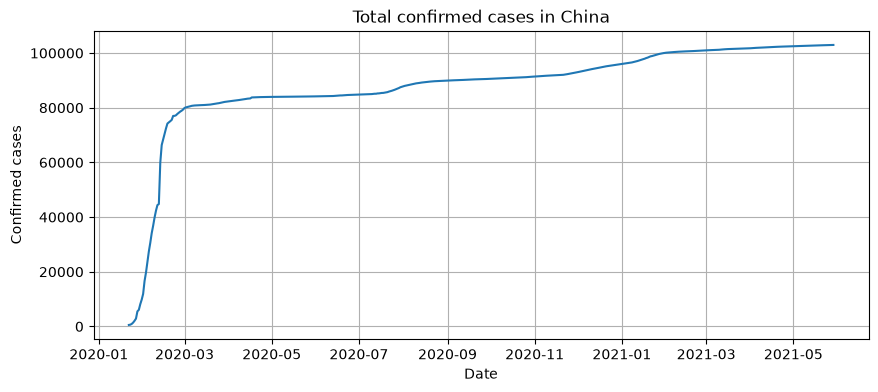

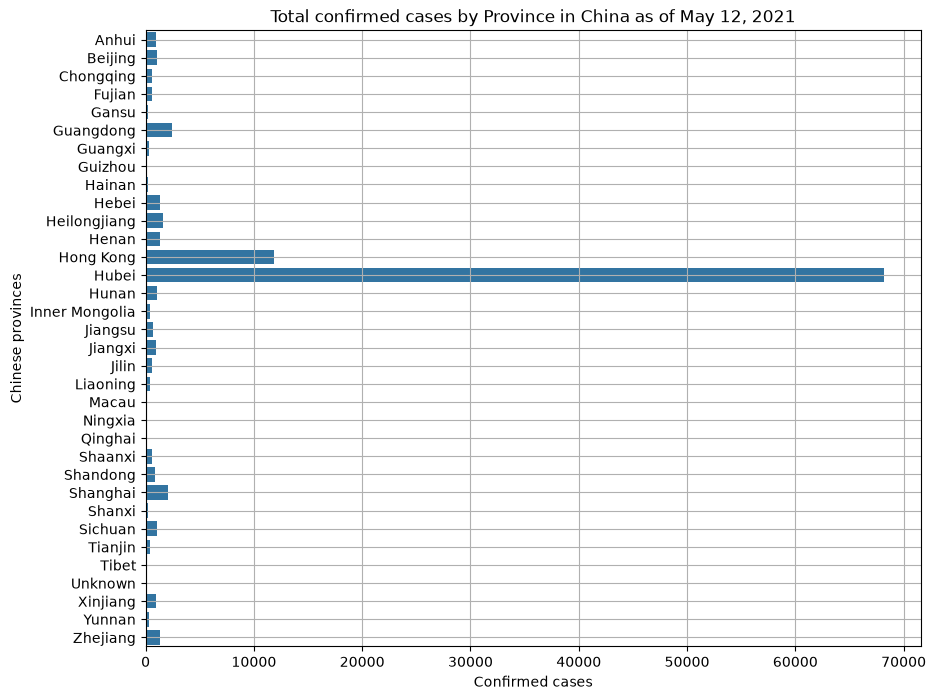

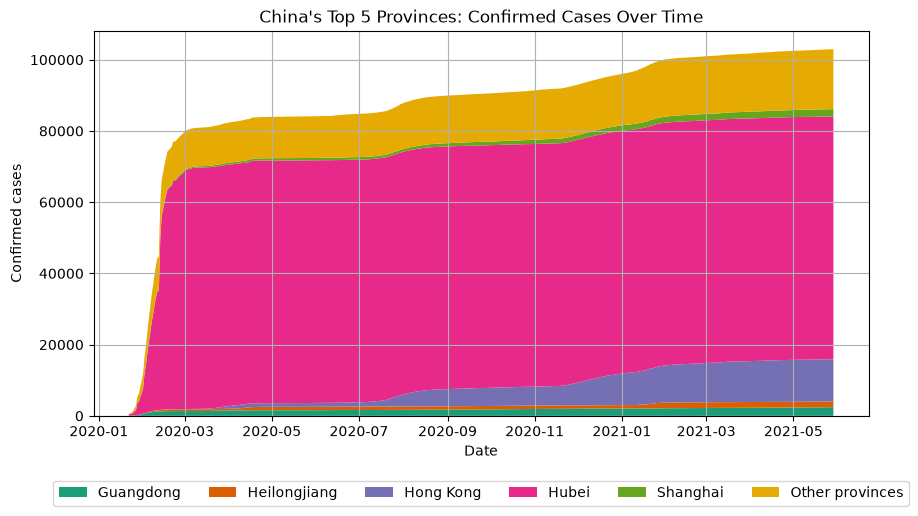

In [204]:
df_china_confirmed_cases = df_confirmed[df_confirmed["Country/Region"] == "China"].copy()

df_china_confirmed_date_cols = pd.concat(
    [df_china_confirmed_cases["Province/State"], df_china_confirmed_cases.iloc[:, 4:]],
    axis=1,
)
df_china_confirmed_province_cols = (
    df_china_confirmed_date_cols.copy()
    .set_index("Province/State")
    .T.reset_index()
    .rename(columns={"index": "Date"})
)

df_china_confirmed_province_cols["total cases by date"] = df_china_confirmed_province_cols.iloc[
    :, 1:
].sum(axis=1)

# line chart: total cases by date
plt.figure(figsize=(10, 4))
sns.lineplot(data=df_china_confirmed_province_cols, x="Date", y="total cases by date")
plt.xlabel("Date")
plt.ylabel("Confirmed cases")
plt.title("Total confirmed cases in China")
plt.grid()
plt.show()

# bar chart: district distribution
df_china_confirmed_bar_plot = pd.concat(
    [df_china_confirmed_date_cols["Province/State"], df_china_confirmed_date_cols.iloc[:, -1]],
    axis=1,
)
df_china_confirmed_bar_plot.columns = [
    "Province/State",
    "cases_2021_05_12",
]  # 2021_05_12 being the last day in our dataset
plt.figure(figsize=(10, 8))
sns.barplot(df_china_confirmed_bar_plot, y="Province/State", x="cases_2021_05_12")
plt.title("Total confirmed cases by Province in China as of May 12, 2021")
plt.xlabel("Confirmed cases")
plt.ylabel("Chinese provinces")
plt.grid()
plt.show()

# stacked area chart: province-wise trend
df_china_confirmed_stack_plot = df_china_confirmed_province_cols.drop(
    columns=["total cases by date"], errors="ignore"
)
n = 5
top_n_provinces = (
    df_china_confirmed_stack_plot.iloc[-1, 1:].astype(float).nlargest(n).index.to_list()
)
other_provinces = []
for province in df_china_confirmed_stack_plot.columns[1:]:
    if province not in top_n_provinces:
        other_provinces.append(province)

df_china_confirmed_stack_plot["Other provinces"] = df_china_confirmed_stack_plot.loc[
    :, other_provinces
].sum(axis=1)
df_china_confirmed_stack_plot = df_china_confirmed_stack_plot.drop(columns=other_provinces)

plt.figure(figsize=(10, 5))
province_col_list = []
province_names = []
for province_name in df_china_confirmed_stack_plot.columns[1:]:
    province_col_list.append(df_china_confirmed_stack_plot[province_name])
    province_names.append(province_name)
plt.stackplot(
    df_china_confirmed_stack_plot["Date"],
    *province_col_list,
    labels=province_names,
    colors=plt.cm.Dark2.colors[: n + 1],
)
plt.title("China's Top 5 Provinces: Confirmed Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Confirmed cases")
plt.legend(bbox_to_anchor=(0.5, -0.15), loc="upper center", ncol=6)
plt.grid()
plt.show()


- From the charts above, we see the number of confirmed cases rose sharply until around March 2020 and then almost plateaued, with the rate of growth declining significantly. This coincides with the implementation of measures such as social distancing, lock-downs and mask-wearing, which may have contributed to slowing the spread.
- From the province-wise breakdown of cases in both the bar-chart and stacked-area-chart, we can see that Hubei which contains Wuhan city, was the epicenter of the outbreak in China and had the highest number of confirmed cases.

### **4.2 Confirmed cases over time for top 5 countries**

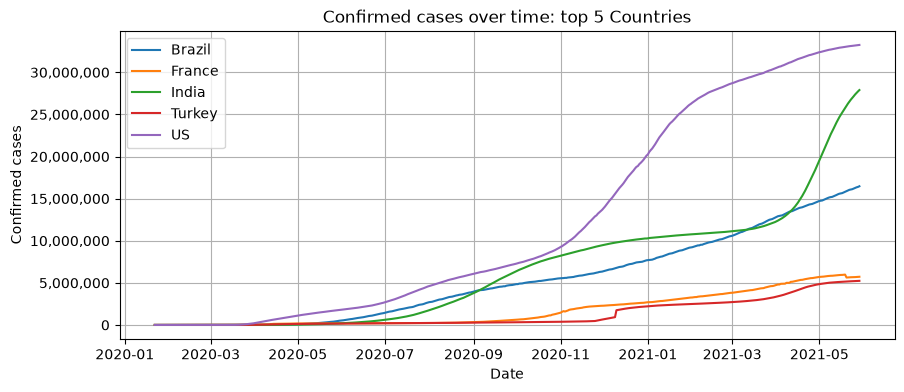

In [205]:
df_country_last_day_cases = df_confirmed.iloc[:, [1, -1]].copy()
df_country_last_day_cases.columns = [
    "Country/Region",
    "cases_2021_05_12",
]  # 2021_05_12 being the last day in our dataset

df_top_5_countries_total_case_count = (
    df_country_last_day_cases.groupby("Country/Region")
    .agg({"cases_2021_05_12": "sum"})
    .reset_index()
    .rename(columns={"cases_2021_05_12": "total_cases"})
    .nlargest(n=5, columns="total_cases")
)
top_5_countries = df_top_5_countries_total_case_count["Country/Region"].values.tolist()
top_5_countries.sort()

df_confirmed_top_5_countries = df_confirmed[
    df_confirmed["Country/Region"].isin(top_5_countries)
].copy()
df_confirmed_top_5_countries = pd.concat(
    [df_confirmed_top_5_countries["Country/Region"], df_confirmed_top_5_countries.iloc[:, 4:]],
    axis=1,
)
df_confirmed_top_5_countries = (
    df_confirmed_top_5_countries.groupby("Country/Region").sum().T.reset_index(names="Date")
)

plt.figure(figsize=(10, 4))
for country in top_5_countries:
    sns.lineplot(df_confirmed_top_5_countries, x="Date", y=country, label=country)
plt.xlabel("Date")
plt.ylabel("Confirmed cases")
plt.title("Confirmed cases over time: top 5 Countries")

# show normal numbers on y axis not scientific notation
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.grid()
plt.show()

- Despite being the epicenter of the global pandemic, China didn't rank among the top 5 countries with the highest confirmed covid-19 cases as of May 12, 2021.
- Even among top 5 countries, US had largely been dominating with consistently higher number of confirmed cases compared to the other 4 countries.
- India started with slightly lower cases than Brazil but surpassed Brazil around September-2020. It then fell behind Brazil again around March-2021 before experiencing another sharp rise around May-2021 and surpassing Brazil once again.
- Among top 5 countries, France and Turkey had the least number of confirmed cases and almost very similar number of cases throughout the timeline, with France leading by a tiny margin and the gap in both country's confirmed cases being the highest around December-2020.

### **4.3 Peak daily new cases: Germany, France & Italy**

In [206]:
countries = ["Germany", "France", "Italy"]
df_countries = df_confirmed[df_confirmed["Country/Region"].isin(countries)].copy()
df_countries = pd.concat(
    [
        df_countries["Country/Region"],
        df_countries.iloc[:, 4:],
    ],
    axis=1,
)

df_cumulative = df_countries.groupby("Country/Region").sum()
df_daily_new = df_cumulative.diff(axis=1)
df_daily_new.iloc[:, 0] = 0

peak_cases = df_daily_new.max(axis=1)
peak_dates = df_daily_new.idxmax(axis=1)

df_peak_summary = pd.DataFrame(
    {
        "peak_daily_new_cases": peak_cases,
        "peak_date": peak_dates,
    }
).sort_values("peak_daily_new_cases", ascending=False)

display(df_peak_summary)


,peak_daily_new_cases,peak_date
Country/Region,,
France,117900.0,2021-04-11
Germany,49044.0,2020-12-30
Italy,40902.0,2020-11-13


**France** had the highest single-day surge: 117900 cases on 11 March 2021.


### **4.4 Recovery rate comparison: Canada vs Australia (as of 31 Dec 2020)**


In [207]:
target_countries = ["Canada", "Australia"]
target_date_str = "2020-12-31"
target_date = pd.to_datetime(target_date_str)

df_confirmed_target_countries_on_target_date = df_confirmed[
    df_confirmed["Country/Region"].isin(target_countries)
][["Country/Region", target_date]].copy()
df_confirmed_target_countries_on_target_date = (
    df_confirmed_target_countries_on_target_date.groupby("Country/Region")
    .sum()
    .rename(columns={target_date: "confirmed_cases"})
)


df_recovered_target_countries_on_target_date = df_recovered[
    df_recovered["Country/Region"].isin(target_countries)
][["Country/Region", target_date]].copy()
df_recovered_target_countries_on_target_date = (
    df_recovered_target_countries_on_target_date.groupby("Country/Region")
    .sum()
    .rename(columns={target_date: "recovered_cases"})
)

df_recovery_rate = pd.concat(
    [df_recovered_target_countries_on_target_date, df_confirmed_target_countries_on_target_date],
    axis=1,
)
df_recovery_rate["Recovery rate"] = (
    (df_recovery_rate["recovered_cases"] / df_recovery_rate["confirmed_cases"]) * 100
).round(2)
df_recovery_rate.rename(columns={})
display(df_recovery_rate)


,recovered_cases,confirmed_cases,Recovery rate
Country/Region,,,
Australia,25554.0,28425.0,89.90
Canada,493638.0,584410.0,84.47


Canada displayed a higher recovery rate of 84.47% compared to Australia's 79.38% recovery rate pointing towards Canada's better pandemic management as on 31 Dec 2020.


### **4.5 Death rates among canadian provinces**

,death_cases,confirmed_cases,death_rate
Province/State,,,
Diamond Princess,1.0,1.0,100.00
Quebec,11125.0,369728.0,3.01
Yukon,2.0,84.0,2.38
Manitoba,1045.0,50499.0,2.07
New Brunswick,43.0,2191.0,1.96
Ontario,8698.0,537138.0,1.62
Nova Scotia,84.0,5530.0,1.52
British Columbia,1692.0,143581.0,1.18
Saskatchewan,537.0,46464.0,1.16


**Highest death rate:** Diamond Princess (100.00%)

**Lowest death rate:** Repatriated Travellers (0.00%)

**Lowest death rate (excluding cruise ships):** Northwest Territories (0.00%)

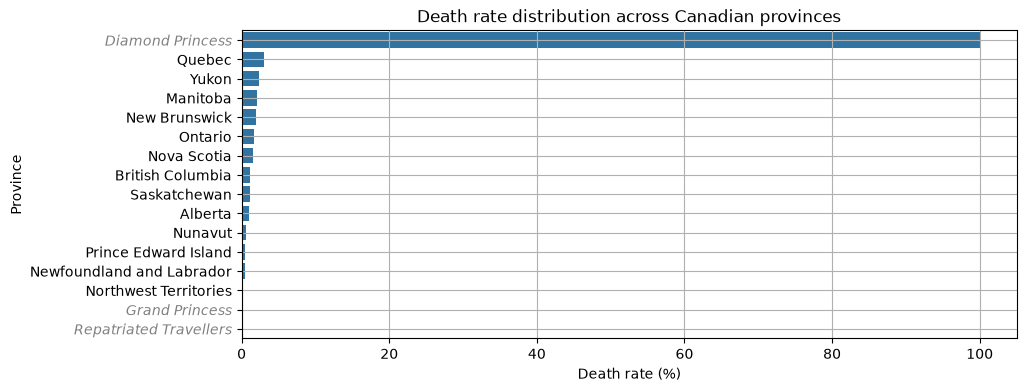

In [208]:
df_total_confirmed_canada = df_confirmed[df_confirmed["Country/Region"] == "Canada"]
df_total_confirmed_canada = df_total_confirmed_canada.iloc[:, [0, -1]]
df_total_confirmed_canada.columns = ["Province/State", "confirmed_cases"]
df_total_confirmed_canada.set_index("Province/State", inplace=True)  # left with just 1 col

df_total_deaths_canada = df_deaths[df_deaths["Country/Region"] == "Canada"]
df_total_deaths_canada = df_total_deaths_canada.iloc[:, [0, -1]]
df_total_deaths_canada.columns = ["Province/State", "death_cases"]
df_total_deaths_canada.set_index("Province/State", inplace=True)  # left with just 1 col

df_death_rate_canadian_provinces = pd.DataFrame(
    {
        "death_cases": df_total_deaths_canada["death_cases"],
        "confirmed_cases": df_total_confirmed_canada["confirmed_cases"],
    }
)
df_death_rate_canadian_provinces["death_rate"] = (
    (
        df_death_rate_canadian_provinces["death_cases"]
        / df_death_rate_canadian_provinces["confirmed_cases"]
    )
    * 100
).round(2)
df_death_rate_canadian_provinces["death_rate"] = df_death_rate_canadian_provinces[
    "death_rate"
].replace(np.inf, 0)
df_death_rate_canadian_provinces = df_death_rate_canadian_provinces.sort_values(
    by=["death_rate", "death_cases", "confirmed_cases"], ascending=[False, False, False]
)

display(df_death_rate_canadian_provinces)
non_provinces = ["Diamond Princess", "Grand Princess", "Repatriated Travellers"]

df_real = df_death_rate_canadian_provinces[
    ~df_death_rate_canadian_provinces.index.isin(non_provinces)
]

display(
    Markdown(
        f"**Highest death rate:** {df_death_rate_canadian_provinces.index[0]} ({df_death_rate_canadian_provinces['death_rate'].iloc[0]:.2f}%)"
    )
)
display(
    Markdown(
        f"**Lowest death rate:** {df_death_rate_canadian_provinces.index[-1]} ({df_death_rate_canadian_provinces['death_rate'].iloc[-1]:.2f}%)"
    )
)
display(
    Markdown(
        f"**Lowest death rate (excluding cruise ships):** {df_real.index[-1]} ({df_real['death_rate'].iloc[-1]:.2f}%)"
    )
)

# bar chart for canadian provinces
plt.figure(figsize=(10, 4))
sns.barplot(
    x=df_death_rate_canadian_provinces["death_rate"],
    y=df_death_rate_canadian_provinces.index,
)
plt.xlabel("Death rate (%)")
plt.ylabel("Province")
plt.title("Death rate distribution across Canadian provinces")
# grayed-out cruise ships disguised as districts
ax = plt.gca()
for tick_label in ax.get_yticklabels():
    if tick_label.get_text() in non_provinces:
        tick_label.set_color("gray")
        tick_label.set_style("italic")

plt.grid()
plt.show()

- Quebec has the **Highest death rate**, at 3.01%.
- Repatriated Travellers has the **Lowest death rate**, at 0.00%.
- Although Canadian Provinces in this dataset include names that belong to cruise ships(Diamond Princess, Grand Princess, Repatriated Travellers), if we exclude them, Northwest Territories has the **Lowest death rate among actual provinces/territories (excluding cruise ship entries)**, at 0.00%.
- Several provinces/territories tied at a 0.00% death rate (Prince Edward Island, Northwest Territories), so `death_cases` and `confirmed_cases` were used as secondary sorting criteria/tiebreakers, provinces with more confirmed cases and deaths are ranked above those with fewer, among entries that share the same death rate.
- Diamond Princess, Grand Princess, and Repatriated Travellers are cruise ship/repatriation entries rather than actual Canadian provinces or territories. Since including them would distort a province-level comparison, their labels are grayed out and italicized in the chart to visually flag them as excluded from the "lowest death rate province" analysis, while still being visible for transparency rather than silently dropped from the dataset.


# **5. Data transformation**

In [209]:
non_date_cols = ["Province/State", "Country/Region", "Lat", "Long"]
df_deaths_long_format = pd.melt(
    df_deaths, id_vars=non_date_cols, var_name="Date", value_name="death_cases"
)

df_confirmed_long_format = pd.melt(
    df_confirmed, id_vars=non_date_cols, var_name="Date", value_name="confirmed_cases"
)

df_recovered_long_format = pd.melt(
    df_recovered, id_vars=non_date_cols, var_name="Date", value_name="recovered_cases"
)

df_deaths_long_format["Date"] = pd.to_datetime(df_deaths_long_format["Date"])
df_confirmed_long_format["Date"] = pd.to_datetime(df_confirmed_long_format["Date"])
df_recovered_long_format["Date"] = pd.to_datetime(df_recovered_long_format["Date"])

display(Markdown("**Subset of long-form confirmed cases data-set:**"))
display(df_confirmed_long_format.iloc[0:5, :])
display(Markdown("**Subset of long-form death cases data-set:**"))
display(df_deaths_long_format.iloc[0:5, :])
display(Markdown("**Subset of long-form recovered cases data-set:**"))
display(df_recovered_long_format.iloc[0:5, :])

**Subset of long-form confirmed cases data-set:**

,Province/State,Country/Region,Lat,Long,Date,confirmed_cases
0,All Provinces,Afghanistan,33.93911,67.709953,2020-01-22,0.0
1,All Provinces,Albania,41.15330,20.168300,2020-01-22,0.0
2,All Provinces,Algeria,28.03390,1.659600,2020-01-22,0.0
3,All Provinces,Andorra,42.50630,1.521800,2020-01-22,0.0
4,All Provinces,Angola,-11.20270,17.873900,2020-01-22,0.0


**Subset of long-form death cases data-set:**

,Province/State,Country/Region,Lat,Long,Date,death_cases
0,All Provinces,Afghanistan,33.93911,67.709953,2020-01-22,0.0
1,All Provinces,Albania,41.15330,20.168300,2020-01-22,0.0
2,All Provinces,Algeria,28.03390,1.659600,2020-01-22,0.0
3,All Provinces,Andorra,42.50630,1.521800,2020-01-22,0.0
4,All Provinces,Angola,-11.20270,17.873900,2020-01-22,0.0


**Subset of long-form recovered cases data-set:**

,Province/State,Country/Region,Lat,Long,Date,recovered_cases
0,All Provinces,Afghanistan,33.93911,67.709953,2020-01-22,0.0
1,All Provinces,Albania,41.15330,20.168300,2020-01-22,0.0
2,All Provinces,Algeria,28.03390,1.659600,2020-01-22,0.0
3,All Provinces,Andorra,42.50630,1.521800,2020-01-22,0.0
4,All Provinces,Angola,-11.20270,17.873900,2020-01-22,0.0


# **6. Deaths dataset: Aggregate analysis**

### **6.1 Total deaths reported per country**

In [210]:
max_date = df_deaths_long_format["Date"].max()
df_deaths_per_country = (
    df_deaths_long_format[df_deaths_long_format["Date"] == max_date]
    .groupby("Country/Region")["death_cases"]
    .sum()
    .sort_values(ascending=False)
    .rename("total_deaths")
    .reset_index()
)

display(Markdown("**Top 10 countries by total deaths:**"))
display(df_deaths_per_country.head(10))
display(Markdown("**Bottom 10 countries by total deaths:**"))
display(df_deaths_per_country.tail(10))

fig = px.treemap(
    df_deaths_per_country,
    path=["Country/Region"],
    values="total_deaths",
    title="Total deaths reported per country (up to latest date)",
    width=1000,
    height=600,
)
fig.show()

**Top 10 countries by total deaths:**

,Country/Region,total_deaths
0,US,594306.0
1,Brazil,461057.0
2,India,325972.0
3,Mexico,223455.0
4,United Kingdom,128038.0
5,Italy,126002.0
6,Russia,118781.0
7,France,109518.0
8,Germany,88413.0
9,Colombia,87747.0


**Bottom 10 countries by total deaths:**

,Country/Region,total_deaths
183,Vanuatu,1.0
184,Grenada,1.0
185,Dominica,0.0
186,Marshall Islands,0.0
187,Holy See,0.0
188,Kiribati,0.0
189,Micronesia,0.0
190,Solomon Islands,0.0
191,Samoa,0.0
192,Saint Kitts and Nevis,0.0


- US reported the highest total number of covid-19 deaths as of 12 May 2021, followed by Brazil and India.
- The distribution of reported deaths varies significantly across the 193 countries, with a relatively small number of countries accounting for a large share of the total reported deaths.

### **6.2 Top 5 countries: highest average daily deaths**

**Top 5 countries with the highest average daily deaths:**

,Country/Region,avg_deaths_per_day
0,US,1205.49
1,Brazil,935.21
2,India,661.20
3,Mexico,453.26
4,United Kingdom,259.71


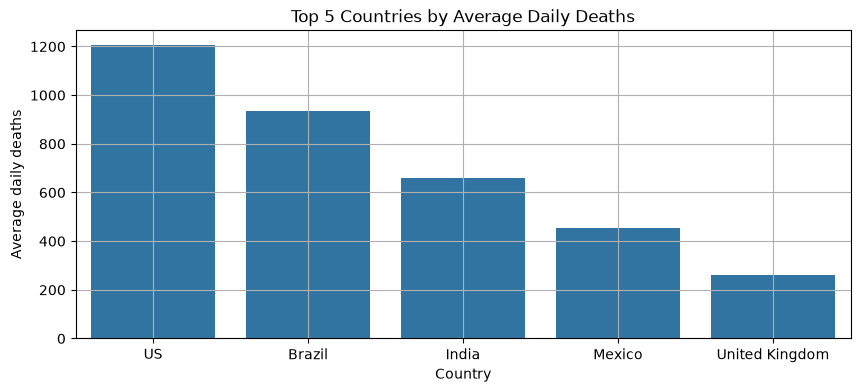

In [211]:
# add all province level deaths on same date to same country
df_deaths_by_country_and_date = (
    df_deaths_long_format.groupby(["Country/Region", "Date"])["death_cases"].sum().reset_index()
)

# ensure dates are in chronological order for diff(new deaths on that date) calculation
df_deaths_by_country_and_date = df_deaths_by_country_and_date.sort_values(
    by=["Country/Region", "Date"], ascending=[True, True]
)


# prepare new deaths column(within country level)
def get_new_deaths(x):
    return pd.DataFrame({"death_cases": x["death_cases"], "new_deaths": x["death_cases"].diff()})


df_deaths_by_country_and_date = (
    df_deaths_by_country_and_date.groupby("Country/Region").apply(get_new_deaths).reset_index()
)

df_average_daily_death_by_country = (
    df_deaths_by_country_and_date.groupby("Country/Region")["new_deaths"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
    .rename("avg_deaths_per_day")
    .reset_index()
)

top_5_highest_daily_average_deaths = df_average_daily_death_by_country[0:5]
display(Markdown("**Top 5 countries with the highest average daily deaths:**"))
display(top_5_highest_daily_average_deaths)

plt.figure(figsize=(10, 4))
sns.barplot(top_5_highest_daily_average_deaths, x="Country/Region", y="avg_deaths_per_day")
plt.xlabel("Country")
plt.ylabel("Average daily deaths")
plt.title("Top 5 Countries by Average Daily Deaths")
plt.grid()
plt.show()

- US had the highest average number of reported daily deaths, followed by Brazil, India, Mexico, and the United Kingdom.
- The top 5 countries with highest average daily deaths are the same five countries as the "total deaths" ranking (US, Brazil, India, Mexico and United Kingdom), suggesting these countries' high totals reflect sustained high death rates over time, not just a short severe spike.

### **6.3 US total deaths: Trend over time**

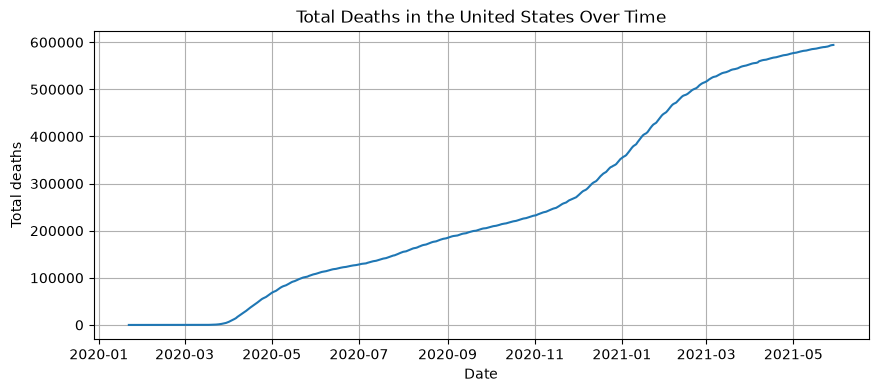

In [212]:
# merge deaths on a date, distributed by US province
# although not really needed here because US has no province level separation in our dataset
df_US_deaths = (
    df_deaths_long_format[df_deaths_long_format["Country/Region"] == "US"]
    .groupby("Date")["death_cases"]
    .sum()
    .reset_index()
    .sort_values(by="Date", ascending=True)
)

plt.figure(figsize=(10, 4))
sns.lineplot(
    data=df_US_deaths,
    x="Date",
    y="death_cases",
)
plt.xlabel("Date")
plt.ylabel("Total deaths")
plt.title("Total Deaths in the United States Over Time")
plt.grid()
plt.show()

US total deaths rose sharply starting from around March 2020, then climbed at a steadier pace through mid-to-late 2020. A second, more accelerated rise is visible from roughly December 2020 through March 2021, consistent with a winter wave, after which the growth rate slows again into mid-2021.

# **7. Data Merging**

### **7.1 Merging Confirmed, Deaths, and Recovered Datasets**

In [213]:
df_deaths_country_long = df_deaths_long_format.groupby(["Country/Region", "Date"])[
    "death_cases"
].sum()

df_confirmed_country_long = df_confirmed_long_format.groupby(["Country/Region", "Date"])[
    "confirmed_cases"
].sum()

df_recovered_country_long = df_recovered_long_format.groupby(["Country/Region", "Date"])[
    "recovered_cases"
].sum()

# merging on index but index is composed of Country/Region and Date
df_merged = (
    pd.merge(
        left=df_deaths_country_long,
        right=df_confirmed_country_long,
        how="outer",
        left_index=True,
        right_index=True,
    )
    .merge(df_recovered_country_long, how="outer", left_index=True, right_index=True)
    .reset_index()
)
display(Markdown("**Subset of merged dataset:**"))
display(df_merged[0:5])
display(
    Markdown(
        f"**No. of rows in long form confirmed dataset:** {df_confirmed_country_long.shape[0]}"
    )
)
display(Markdown(f"**No. of rows in long form deaths dataset:** {df_deaths_country_long.shape[0]}"))
display(
    Markdown(
        f"**No. of rows in long form recovered dataset:** {df_recovered_country_long.shape[0]}"
    )
)
display(Markdown(f"**No. of rows in final 'merged' dataset:** {df_merged.shape[0]}"))
print()
display(Markdown(f"**Null values in merged dataset:** {df_merged.isna().sum().sum()}"))


**Subset of merged dataset:**

,Country/Region,Date,death_cases,confirmed_cases,recovered_cases
0,Afghanistan,2020-01-22,0.0,0.0,0.0
1,Afghanistan,2020-01-23,0.0,0.0,0.0
2,Afghanistan,2020-01-24,0.0,0.0,0.0
3,Afghanistan,2020-01-25,0.0,0.0,0.0
4,Afghanistan,2020-01-26,0.0,0.0,0.0


**No. of rows in long form confirmed dataset:** 95342

**No. of rows in long form deaths dataset:** 95342

**No. of rows in long form recovered dataset:** 95342

**No. of rows in final 'merged' dataset:** 95342

**Null values in merged dataset:** 0

- The death cases, confirmed cases, and recovered cases datasets were merged on `Country/Region` and `Date` after aggregating the province/state-level data to the country level.
- Merging the country-level confirmed, deaths, and recovered datasets on `Country/Region` and `Date`, using `how="outer"` to preserve any dates-country combination not present across all 3 datasets, it resulted in **zero null values** and identical row counts across all 3 source datasets. This confirms all 3 datasets have matching country and date coverage, so no data was lost or misaligned during the merge, and there are no coverage gaps to account for going forward.
- The merged dataset contains 0 `null` values, confirming that every country-date record has corresponding confirmed cases, deaths, and recovered cases data.


### **7.2 Monthly case progression**

**Top 15 country-months by new confirmed cases:**

,Country/Region,month-year_period,new_confirmed_cases,new_death_cases,new_recovered_cases
1359,India,2021-05,8729831.0,114119.0,9769914.0
1358,India,2021-04,6943304.0,48926.0,4209723.0
3054,US,2020-12,6429031.0,81143.0,1151763.0
3055,US,2021-01,6147690.0,97285.0,0.0
3053,US,2020-11,4504713.0,39271.0,1533841.0
1351,India,2020-09,2621418.0,33390.0,2433319.0
3056,US,2021-02,2401691.0,65636.0,0.0
405,Brazil,2021-03,2197488.0,66573.0,1799055.0
1350,India,2020-08,1995178.0,28777.0,1745508.0
3052,US,2020-10,1930191.0,24532.0,771790.0


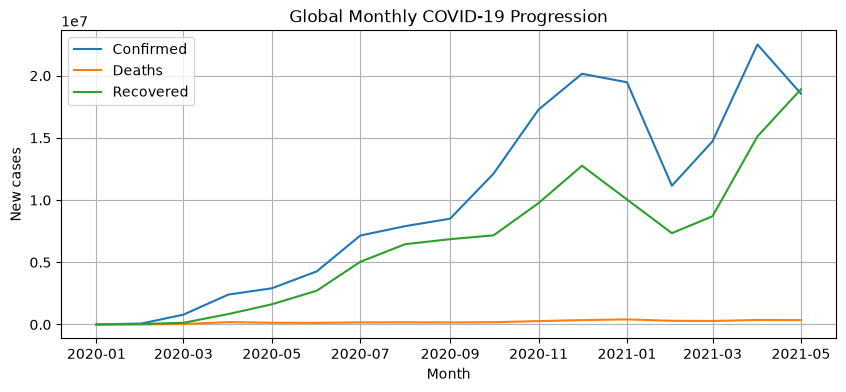

In [214]:
df_monthly_cases_by_country = df_merged.sort_values(["Country/Region", "Date"]).copy()
df_monthly_cases_by_country["month-year_period"] = df_monthly_cases_by_country["Date"].dt.to_period(
    "M"
)

df_monthly_cases_by_country["new_confirmed_cases"] = df_monthly_cases_by_country.groupby(
    "Country/Region"
)["confirmed_cases"].diff()
df_monthly_cases_by_country["new_death_cases"] = df_monthly_cases_by_country.groupby(
    "Country/Region"
)["death_cases"].diff()
df_monthly_cases_by_country["new_recovered_cases"] = df_monthly_cases_by_country.groupby(
    "Country/Region"
)["recovered_cases"].diff()

df_monthly_cases_by_country = (
    df_monthly_cases_by_country.groupby(["Country/Region", "month-year_period"])[
        ["new_confirmed_cases", "new_death_cases", "new_recovered_cases"]
    ]
    .sum()
    .reset_index()
)

display(Markdown("**Top 15 country-months by new confirmed cases:**"))
display(df_monthly_cases_by_country.sort_values("new_confirmed_cases", ascending=False).head(15))

df_global_monthly = (
    df_monthly_cases_by_country.groupby("month-year_period")[
        ["new_confirmed_cases", "new_death_cases", "new_recovered_cases"]
    ]
    .sum()
    .reset_index()
)
df_global_monthly["month-year_period"] = df_global_monthly["month-year_period"].dt.to_timestamp()

plt.figure(figsize=(10, 4))
sns.lineplot(
    data=df_global_monthly, x="month-year_period", y="new_confirmed_cases", label="Confirmed"
)
sns.lineplot(data=df_global_monthly, x="month-year_period", y="new_death_cases", label="Deaths")
sns.lineplot(
    data=df_global_monthly, x="month-year_period", y="new_recovered_cases", label="Recovered"
)
plt.xlabel("Month")
plt.ylabel("New cases")
plt.title("Global Monthly COVID-19 Progression")
plt.grid()
plt.show()